In [303]:
import pandas as pd
import numpy as np


df = pd.read_csv('dataset.csv')

In [304]:
df['Timestamp']

0        Jan 26, 2026, 12:00:03 AM
1        Jan 26, 2026, 12:00:03 AM
2        Jan 26, 2026, 12:00:03 AM
3        Jan 26, 2026, 12:00:03 AM
4        Jan 26, 2026, 12:00:03 AM
                   ...            
31245    Jan 26, 2026, 12:05:47 AM
31246    Jan 26, 2026, 12:05:47 AM
31247    Jan 26, 2026, 12:05:47 AM
31248    Jan 26, 2026, 12:05:47 AM
31249    Jan 26, 2026, 12:05:47 AM
Name: Timestamp, Length: 31250, dtype: object

In [305]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from datetime import datetime

df = pd.read_csv('dataset.csv')

def parse_ts(s):
    return datetime.strptime(s, 'Jan %d, %Y, %I:%M:%S %p')
df['Timestamp_DT'] = df['Timestamp'].apply(parse_ts)
df['seconds'] = df['Timestamp_DT'].dt.second + df['Timestamp_DT'].dt.minute*60

In [306]:
df

,Name,Timestamp,X,Y,Timestamp_DT,seconds
0,qdugzqd,"Jan 26, 2026, 12:00:03 AM",54.019410,69.212326,2026-01-26 00:00:03,3
1,qdugzqd,"Jan 26, 2026, 12:00:03 AM",176.670391,66.628831,2026-01-26 00:00:03,3
2,qdugzqd,"Jan 26, 2026, 12:00:03 AM",185.917840,105.632155,2026-01-26 00:00:03,3
3,qdugzqd,"Jan 26, 2026, 12:00:03 AM",127.891247,52.613789,2026-01-26 00:00:03,3
4,qdugzqd,"Jan 26, 2026, 12:00:03 AM",89.019781,36.288286,2026-01-26 00:00:03,3
...,...,...,...,...,...,...
31245,qktoljz,"Jan 26, 2026, 12:05:47 AM",96.937658,154.996148,2026-01-26 00:05:47,347
31246,qktoljz,"Jan 26, 2026, 12:05:47 AM",247.110509,136.630830,2026-01-26 00:05:47,347
31247,qktoljz,"Jan 26, 2026, 12:05:47 AM",263.030374,169.473477,2026-01-26 00:05:47,347
31248,qktoljz,"Jan 26, 2026, 12:05:47 AM",187.661756,110.167398,2026-01-26 00:05:47,347


In [307]:
res1 = pd.DataFrame({
    'id': 'GLOBAL',
    'subtaskID': 'task1',
    'answer': len(df['Timestamp'].unique())
}, index=[0])
res2 = pd.DataFrame({
    'id': 'GLOBAL',
    'subtaskID': 'task2',
    'answer': 5
}, index=[0])


In [308]:

df['num_id'] = (range(len(df)))
df

,Name,Timestamp,X,Y,Timestamp_DT,seconds,num_id
0,qdugzqd,"Jan 26, 2026, 12:00:03 AM",54.019410,69.212326,2026-01-26 00:00:03,3,0
1,qdugzqd,"Jan 26, 2026, 12:00:03 AM",176.670391,66.628831,2026-01-26 00:00:03,3,1
2,qdugzqd,"Jan 26, 2026, 12:00:03 AM",185.917840,105.632155,2026-01-26 00:00:03,3,2
3,qdugzqd,"Jan 26, 2026, 12:00:03 AM",127.891247,52.613789,2026-01-26 00:00:03,3,3
4,qdugzqd,"Jan 26, 2026, 12:00:03 AM",89.019781,36.288286,2026-01-26 00:00:03,3,4
...,...,...,...,...,...,...,...
31245,qktoljz,"Jan 26, 2026, 12:05:47 AM",96.937658,154.996148,2026-01-26 00:05:47,347,31245
31246,qktoljz,"Jan 26, 2026, 12:05:47 AM",247.110509,136.630830,2026-01-26 00:05:47,347,31246
31247,qktoljz,"Jan 26, 2026, 12:05:47 AM",263.030374,169.473477,2026-01-26 00:05:47,347,31247
31248,qktoljz,"Jan 26, 2026, 12:05:47 AM",187.661756,110.167398,2026-01-26 00:05:47,347,31248


In [309]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import os
os.environ["OMP_NUM_THREADS"] = "3"
th=0.9
new_df =[]

moments = df['Timestamp'].unique()

kmeans = KMeans(n_clusters=5,random_state=42)

for moment in moments:

    snapshot = df[df['Timestamp'] == moment]
    nums = snapshot[['X','Y']]
    second = snapshot['seconds'].unique()[0]
    
    kmeans.fit(nums)
    
    centroids = kmeans.cluster_centers_
    score = silhouette_score(nums,kmeans.predict(nums))
    part_res = [[f'{moment}|{k}', f'{centroids[k][0]}|{centroids[k][1]}'] for k in range(5)]
    for i in range(5):
        if score > th:
            new_df.append({'X':centroids[i][0],'Y':centroids[i][1],'seconds':second,'train':1,'id':part_res[i][0],'answer':part_res[i][1],'drone_ID':i})
        else:
            new_df.append({'X':centroids[i][0],'Y':centroids[i][1],'seconds':second,'train':0,'id':part_res[i][0],'answer':part_res[i][1],'drone_ID':i})
        


C:\Users\Iulian\AppData\Roaming\jupyterlab-desktop\envs\env_3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Iulian\AppData\Roaming\jupyterlab-desktop\envs\env_3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Iulian\AppData\Roaming\jupyterlab-desktop\envs\env_3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Iulian\AppData\R

In [310]:
new_df = pd.DataFrame(new_df)

In [311]:
new_df

,X,Y,seconds,train,id,answer,drone_ID
0,88.762852,35.302498,3,1,"Jan 26, 2026, 12:00:03 AM|0",88.76285239985327|35.30249775743958,0
1,186.822623,104.630508,3,1,"Jan 26, 2026, 12:00:03 AM|1",186.82262314832118|104.63050811654105,1
2,54.628444,68.355124,3,1,"Jan 26, 2026, 12:00:03 AM|2",54.62844385058159|68.35512373510925,2
3,127.111300,52.155437,3,1,"Jan 26, 2026, 12:00:03 AM|3",127.11129974788031|52.155436847756576,3
4,176.662015,67.230412,3,1,"Jan 26, 2026, 12:00:03 AM|4",176.6620150587668|67.23041177368826,4
...,...,...,...,...,...,...,...
245,143.121654,109.887079,347,0,"Jan 26, 2026, 12:05:47 AM|0",143.1216543654472|109.88707870254494,0
246,231.040724,143.000046,347,0,"Jan 26, 2026, 12:05:47 AM|1",231.04072398694427|143.00004631044848,1
247,106.998639,146.483472,347,0,"Jan 26, 2026, 12:05:47 AM|2",106.99863883985036|146.48347163182387,2
248,181.163063,128.875904,347,0,"Jan 26, 2026, 12:05:47 AM|3",181.16306286304507|128.87590410973374,3


In [312]:
from sklearn.linear_model import LinearRegression

train_X, train_Y = new_df.loc[new_df['train'] == 1, ['seconds', 'X', 'drone_ID']].copy(), new_df.loc[new_df['train'] == 1, ['seconds', 'Y', 'drone_ID']].copy()

In [313]:
lx = LinearRegression().fit(train_X[['seconds']], train_X['X'])
ly = LinearRegression().fit(train_Y[['seconds']], train_Y['Y'])

In [314]:
new_df['predX'] = lx.predict(new_df[['seconds']])
new_df['predY'] = ly.predict(new_df[['seconds']])

In [315]:
new_df

,X,Y,seconds,train,id,answer,drone_ID,predX,predY
0,88.762852,35.302498,3,1,"Jan 26, 2026, 12:00:03 AM|0",88.76285239985327|35.30249775743958,0,126.754198,65.506427
1,186.822623,104.630508,3,1,"Jan 26, 2026, 12:00:03 AM|1",186.82262314832118|104.63050811654105,1,126.754198,65.506427
2,54.628444,68.355124,3,1,"Jan 26, 2026, 12:00:03 AM|2",54.62844385058159|68.35512373510925,2,126.754198,65.506427
3,127.111300,52.155437,3,1,"Jan 26, 2026, 12:00:03 AM|3",127.11129974788031|52.155436847756576,3,126.754198,65.506427
4,176.662015,67.230412,3,1,"Jan 26, 2026, 12:00:03 AM|4",176.6620150587668|67.23041177368826,4,126.754198,65.506427
...,...,...,...,...,...,...,...,...,...
245,143.121654,109.887079,347,0,"Jan 26, 2026, 12:05:47 AM|0",143.1216543654472|109.88707870254494,0,180.774477,142.272688
246,231.040724,143.000046,347,0,"Jan 26, 2026, 12:05:47 AM|1",231.04072398694427|143.00004631044848,1,180.774477,142.272688
247,106.998639,146.483472,347,0,"Jan 26, 2026, 12:05:47 AM|2",106.99863883985036|146.48347163182387,2,180.774477,142.272688
248,181.163063,128.875904,347,0,"Jan 26, 2026, 12:05:47 AM|3",181.16306286304507|128.87590410973374,3,180.774477,142.272688


In [316]:
for_r4 = []
for i in range(5):
    tx, ty = train_X[train_X['drone_ID'] == i].copy(), train_Y[train_Y['drone_ID'] == i].copy()
    lx.fit(tx[['seconds']], tx['X'])
    ly.fit(ty[['seconds']], ty['Y'])

    new_df.loc[new_df['drone_ID'] == i, 'predX'] = lx.predict(new_df.loc[new_df['drone_ID'] == i, ['seconds']])
    new_df.loc[new_df['drone_ID'] == i, 'predY'] = ly.predict(new_df.loc[new_df['drone_ID'] == i, ['seconds']])

    for_r4.append(f'{lx.predict([[500]])[0]}|{ly.predict([[500]])[0]}')

C:\Users\Iulian\AppData\Roaming\jupyterlab-desktop\envs\env_3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\Iulian\AppData\Roaming\jupyterlab-desktop\envs\env_3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\Iulian\AppData\Roaming\jupyterlab-desktop\envs\env_3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\Iulian\AppData\Roaming\jupyterlab-desktop\envs\env_3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\Iulian\AppData\Roaming\jupyterlab-desktop\envs\env_3\Lib\site-p

In [317]:
predX = list(new_df['predX'])
predY = list(new_df['predY'])
res3 = pd.DataFrame({
    'id': new_df['id'],
    'subtaskID': 'task3',
    'answer': [f'{predX[i]}|{predY[i]}' for i in range(len(predX))]
})


In [318]:
res4 = pd.DataFrame({
    'id': [f'Jan 26, 2026, 12:08:20 AM|{i}'for i in range(5)],
    'subtaskID': 'task4',
    'answer': for_r4
})
res4

,id,subtaskID,answer
0,"Jan 26, 2026, 12:08:20 AM|0",task4,166.7700938037405|146.1192202799004
1,"Jan 26, 2026, 12:08:20 AM|1",task4,264.97386241479535|215.72726302851498
2,"Jan 26, 2026, 12:08:20 AM|2",task4,132.57028174755465|179.06840319906226
3,"Jan 26, 2026, 12:08:20 AM|3",task4,205.16673503933998|163.07272115039706
4,"Jan 26, 2026, 12:08:20 AM|4",task4,254.52371717816868|178.0915016064089


In [319]:
full = pd.concat([res1,res2,res3,res4])
full.to_csv('submission.csv')

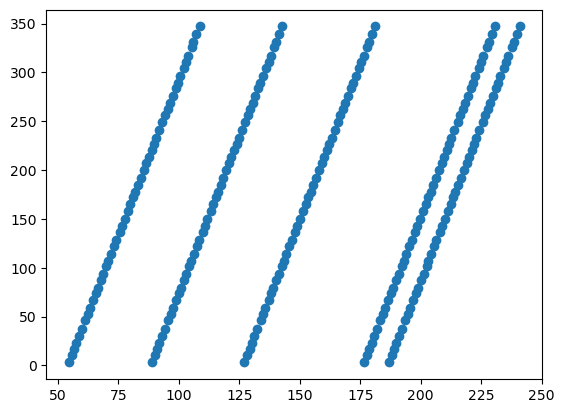

In [320]:
plt.scatter(new_df['predX'],new_df['seconds'])